In [1]:
# Import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.data import loadlocal_mnist
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [2]:
!ls ../data/

emnist-letters-test-images-idx3-ubyte  emnist-letters-train-images-idx3-ubyte
emnist-letters-test-labels-idx1-ubyte  emnist-letters-train-labels-idx1-ubyte


## **Load Dataset**

In [3]:
train_images, train_labels = loadlocal_mnist(images_path='../data/emnist-letters-train-images-idx3-ubyte',
                                             labels_path='../data/emnist-letters-train-labels-idx1-ubyte')

In [4]:
print(f'Train Shape :  {train_images.shape}')
print(f'Train Labels :  {train_labels.shape}')

Train Shape :  (124800, 784)
Train Labels :  (124800,)


## **Use Preprocessing for Dataset**

In [5]:
balanced_train_images = []
balanced_train_labels = []

np.random.seed(42)

for i in range(1, 27):
    indices = np.where(train_labels == i)[0]
    selected_indices = np.random.choice(indices, size=100, replace=False)
    balanced_train_images.append(train_images[selected_indices])
    balanced_train_labels.append(train_labels[selected_indices])

# balanced_train_images.shape, balanced_train_labels.shape
balanced_train_images = np.vstack(balanced_train_images)
balanced_train_labels = np.hstack(balanced_train_labels)

print(f'Shape Balanced Train Images {balanced_train_images.shape}')
print(f'Shape Balanced Train Labels {balanced_train_labels.shape}')

Shape Balanced Train Images (2600, 784)
Shape Balanced Train Labels (2600,)


Text(0.5, 1.0, 'Label A')

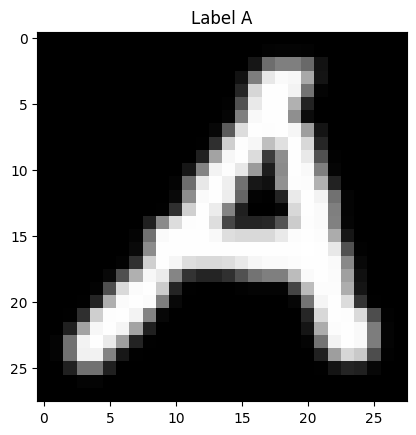

In [6]:
plt.imshow(balanced_train_images[1].reshape(28, 28).T, cmap='gray')
plt.title(f"Label {chr(balanced_train_labels[1] + 64)}")

In [7]:
unique, counts = np.unique(balanced_train_labels, return_counts=True)
labels_as_letters = [chr(label + 64) for label in unique]

print(f"Label : {unique}")
print(f"Jumlah : {counts}")

Label : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26]
Jumlah : [100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100]


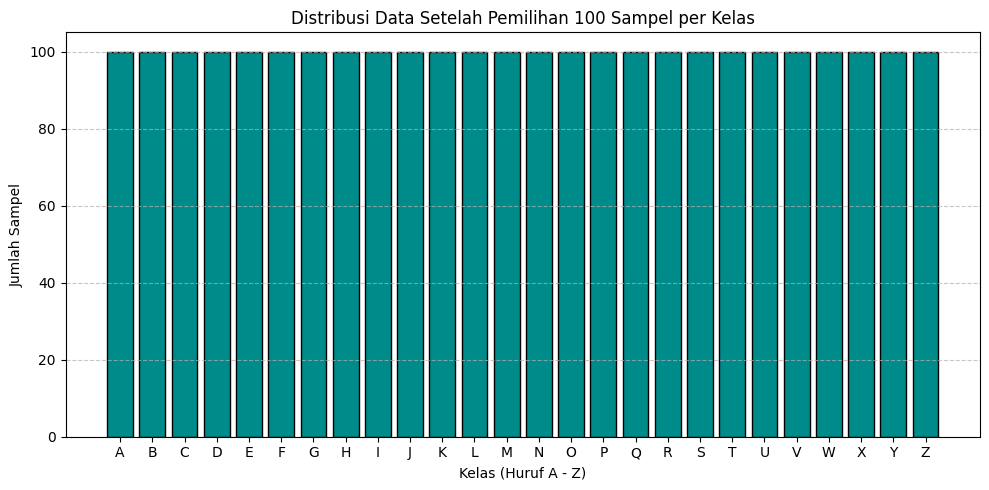

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(labels_as_letters, counts, color='darkcyan', edgecolor='black')
plt.title("Distribusi Data Setelah Pemilihan 100 Sampel per Kelas")
plt.xlabel("Kelas (Huruf A - Z)")
plt.ylabel("Jumlah Sampel")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()

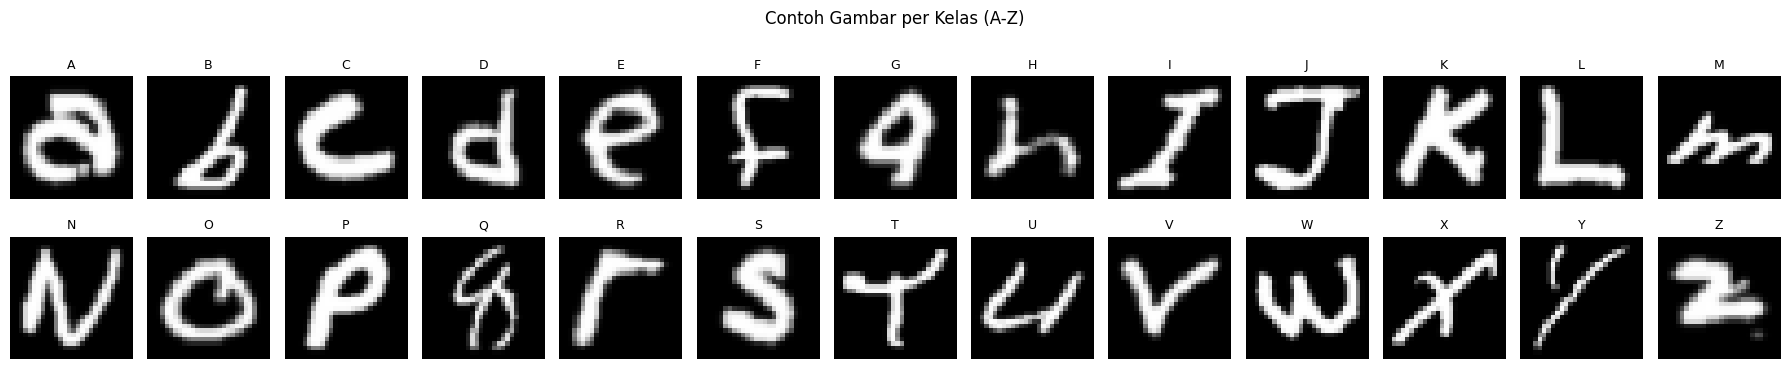

In [9]:
fig, axes = plt.subplots(2, 13, figsize=(18, 4))
for idx, ax in enumerate(axes.flat):
    ax.imshow(balanced_train_images[idx * 100].reshape(28, 28).T, cmap='gray')
    ax.set_title(chr(balanced_train_labels[idx * 100] + 64), fontsize=9)
    ax.axis('off')
plt.suptitle('Contoh Gambar per Kelas (A-Z)', fontsize=12)
plt.tight_layout()

In [10]:
shuffle_idx = np.random.permutation(len(balanced_train_labels))
balanced_train_images = balanced_train_images[shuffle_idx]
balanced_train_labels = balanced_train_labels[shuffle_idx]

## **Feature Extraction – HOG**

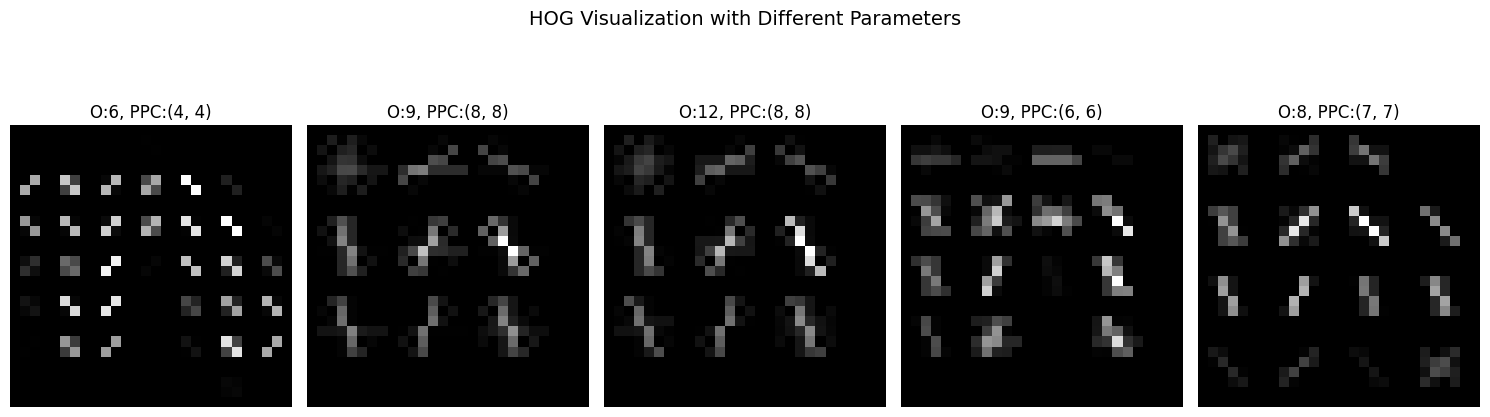

In [11]:
img = balanced_train_images[0].reshape(28, 28).T

param_sets = [
    {"orientations": 6, "pixels_per_cell": (4, 4), "cells_per_block": (2, 2)},
    {"orientations": 9, "pixels_per_cell": (8, 8), "cells_per_block": (2, 2)},
    {"orientations": 12, "pixels_per_cell": (8, 8), "cells_per_block": (3, 3)},
    {"orientations": 9, "pixels_per_cell": (6, 6), "cells_per_block": (2, 2)},
    {"orientations": 8, "pixels_per_cell": (7, 7), "cells_per_block": (2, 2)},
]

plt.figure(figsize=(15, 5))

for i, params in enumerate(param_sets):
    features, hog_image = hog(img, visualize=True, block_norm='L2', **params)
    
    plt.subplot(1, len(param_sets), i + 1)
    plt.imshow(hog_image, cmap='gray')
    plt.title(f"O:{params['orientations']}, PPC:{params['pixels_per_cell']}")
    plt.axis('off')

plt.suptitle("HOG Visualization with Different Parameters", fontsize=14)
plt.tight_layout()

In [12]:
# Menghitung n_dims dari 1 gambar sampel
feature, hog_img = hog(balanced_train_images[0].reshape(28, 28), orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')

n_dims = feature.shape[0]
n_samples = balanced_train_images.shape[0]

print(f'n_dims    = {n_dims}    (jumlah fitur HOG per gambar)')
print(f'n_samples = {n_samples} (total sampel)')

n_dims    = 144    (jumlah fitur HOG per gambar)
n_samples = 2600 (total sampel)


## **Training Dataset**

In [13]:
# Create Train for dataset
X_train, y_train = datasets.make_classification(n_samples, n_dims)

print(f'X_train shape {X_train.shape}')
print(f'y_train shape {y_train.shape}')

X_train shape (2600, 144)
y_train shape (2600,)


In [14]:
# HogFeature Train
for i in range(n_samples):
    X_train[i], _ = hog(balanced_train_images[i].reshape(28, 28), orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
    y_train[i] = balanced_train_labels[i]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y_train)

X_train.shape, y_train.shape, X_test.shape, y_test.shape


((2080, 144), (2080,), (520, 144), (520,))

## **Classification – SVM + Grid Search**
### Use Support Vector Machine (SVM) for classification

In [16]:
from sklearn.svm import SVC
clf = SVC()

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score, classification_report,confusion_matrix

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

param_grid = {
    'C' : [0.1,1,3.2, 5.0, 2.4, 10.0],
    'kernel' : ['rbf', 'linear'],
    'gamma' : ["scale", "auto"]
}
grid_search = GridSearchCV(clf, param_grid, scoring=scoring, cv=5, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
16      {'C': 2.4, 'gamma': 'scale', 'kernel': 'rbf'}            0.788942   
12      {'C': 5.0, 'gamma': 'scale', 'kernel': 'rbf'}            0.787019   
8       {'C': 3.2, 'gamma': 'scale', 'kernel': 'rbf'}            0.787019   
20     {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}            0.784615   
4         {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}            0.772115   
5      {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}            0.765385   
7       {'C': 1, 'gamma': 'auto', 'kernel': 'linear'}            0.765385   
17   {'C': 2.4, 'gamma': 'scale', 'kernel': 'linear'}            0.743269   
19    {'C': 2.4, 'gamma': 'auto', 'kernel': 'linear'}            0.743269   
11    {'C': 3.2, 'gamma': 'auto', 'kernel': 'linear'}            0.740385   
9    {'C': 3.2, 'gamma': 'scale', 'kern

In [18]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'C': 2.4, 'gamma': 'scale', 'kernel': 'rbf'}


## **Evaluation – Leave-One-Out Cross Validation (LOOCV)**
### Use Leave-One-Out-Cross-Validation Evaluation

In [19]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict
loo = LeaveOneOut()
y_pred_loocv = cross_val_predict(best_model, X_train, y_train, cv=loo)
accuracy = accuracy_score(y_train, y_pred_loocv)
print("LOOCV Accuracy: {:.2f}%".format(accuracy * 100))
print("Precision: {:.2f}%".format(precision_score(y_train, y_pred_loocv, average='weighted') * 100))
print("Recall: {:.2f}%".format(recall_score(y_train, y_pred_loocv, average='weighted') * 100))
print("F1 Score: {:.2f}%".format(f1_score(y_train, y_pred_loocv, average='weighted') * 100))

cof_LOOCV = confusion_matrix(y_train, y_pred_loocv)

LOOCV Accuracy: 79.90%
Precision: 80.01%
Recall: 79.90%
F1 Score: 79.84%


Text(0.5, 1.0, 'Confusion Matrix LOOCV 80% Training')

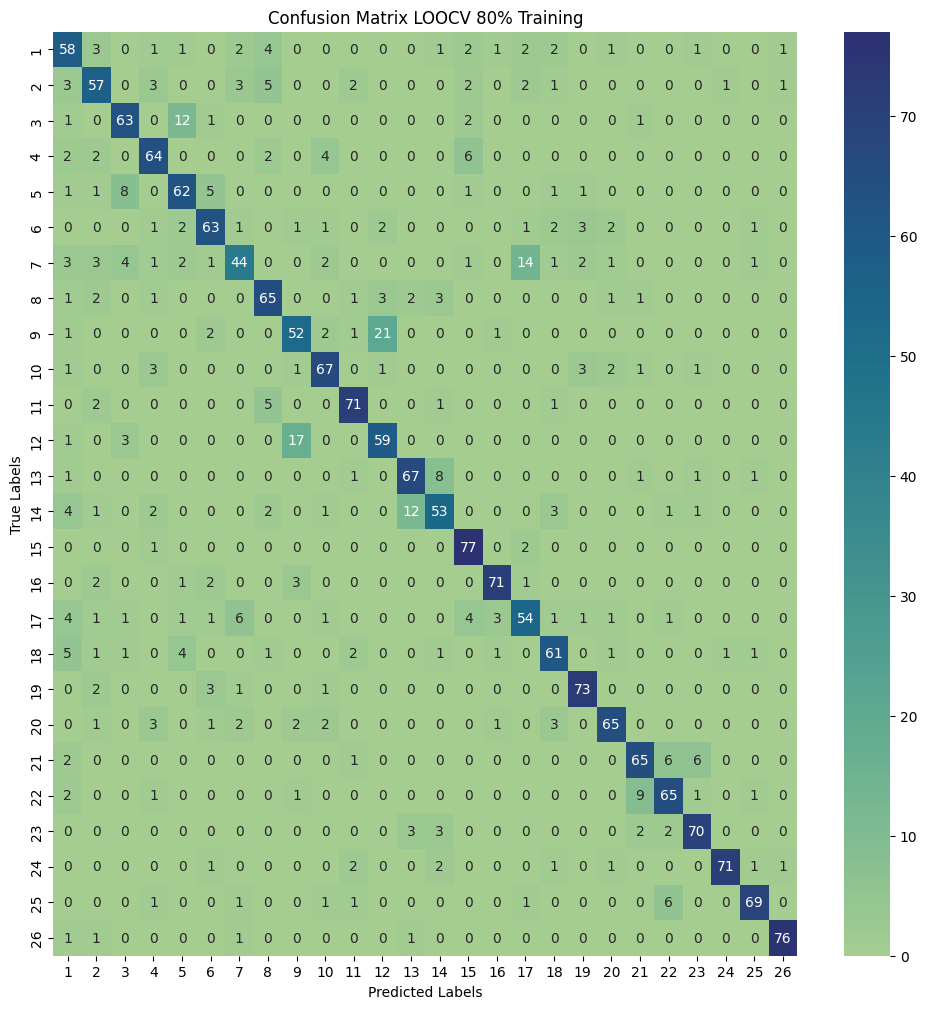

In [20]:
plt.figure(figsize=(12, 12))
sns.heatmap(cof_LOOCV, annot=True, fmt="d", cmap="crest", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix LOOCV 80% Training")

### Use 20% from dataset to Evaluation

In [21]:
pred_test = best_model.predict(X_test)
pred_test = best_model.predict(X_test) 
print("Test Accuracy: {:.2f}%".format(accuracy_score(y_test, pred_test) * 100))
print("Test Precision: {:.2f}%".format(precision_score(y_test, pred_test, average='macro') * 100))
print("Test Recall: {:.2f}%".format(recall_score(y_test, pred_test, average='weighted') * 100))
print("Test F1 Score: {:.2f}%".format(f1_score(y_test, pred_test, average='weighted')* 100))

conf_mat = confusion_matrix(y_test, pred_test)

Test Accuracy: 78.27%
Test Precision: 79.03%
Test Recall: 78.27%
Test F1 Score: 78.18%


Text(0.5, 1.0, 'Confusion Matrix 20% Testing')

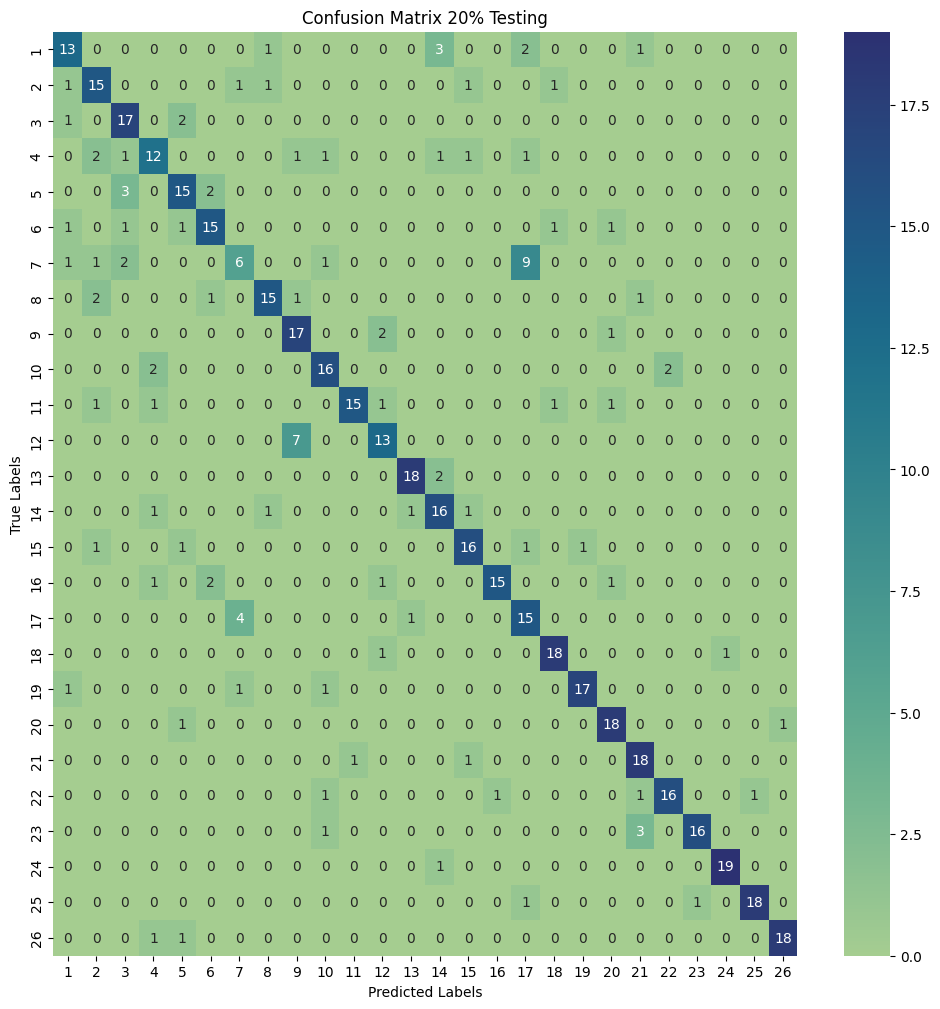

In [22]:
plt.figure(figsize=(12, 12))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="crest", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix 20% Testing")

## **Testing Model - Visualisasi Prediksi**

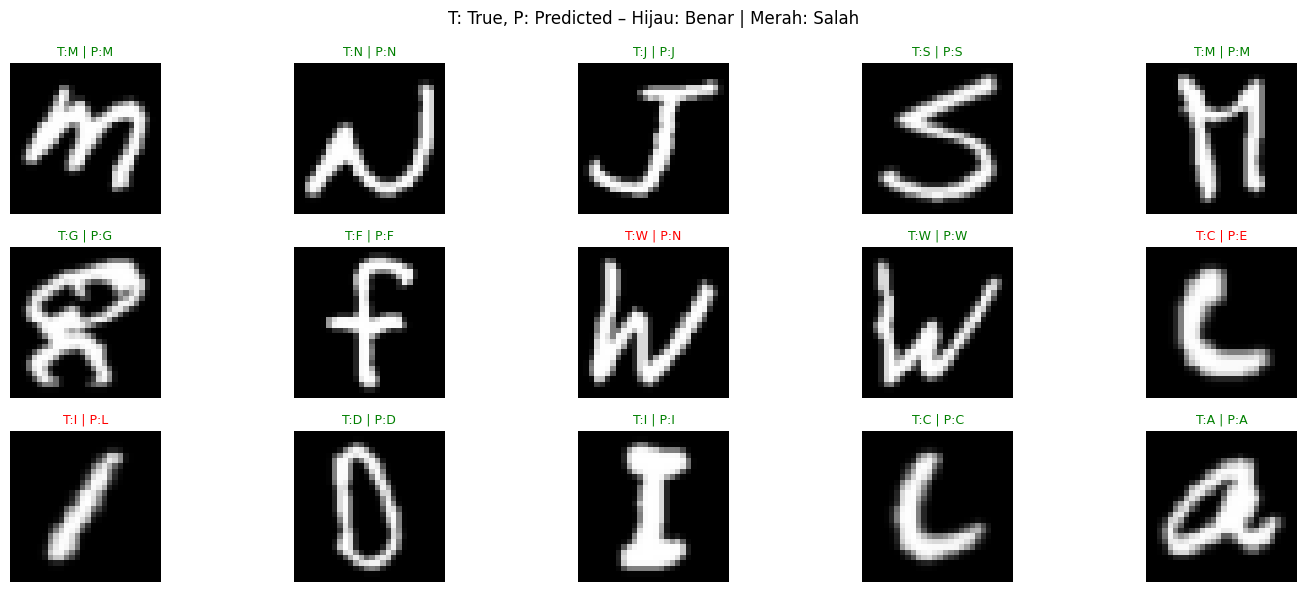

In [23]:
import random
random.seed(0)

indices = random.sample(range(len(X_train)), 15)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    true_label = y_train[idx]
    pred_label = y_pred_loocv[idx]
    color = 'green' if true_label == pred_label else 'red'
    
    img_candidates = np.where(balanced_train_labels == true_label)[0]
    img = balanced_train_images[img_candidates[idx % len(img_candidates)]].reshape(28, 28).T
    
    plt.subplot(3, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{chr(true_label + 64)} | P:{chr(pred_label + 64)}", color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("T: True, P: Predicted – Hijau: Benar | Merah: Salah", fontsize=12)
plt.tight_layout()

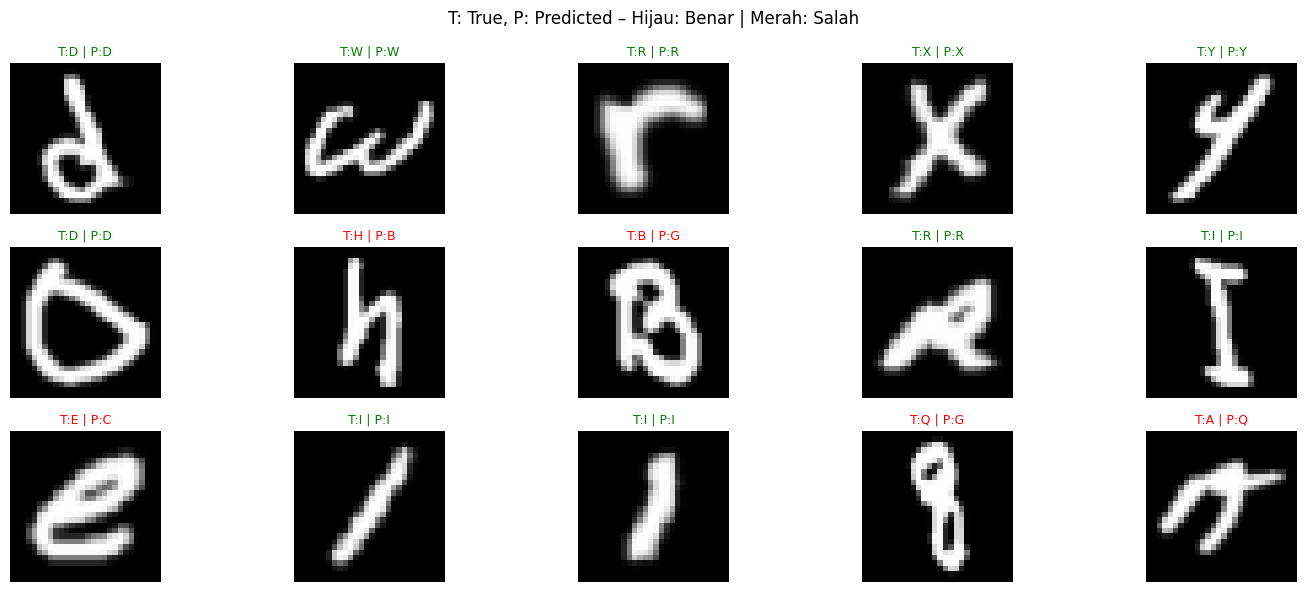

In [24]:
# Visualisasi prediksi pada Test data
indices_test = random.sample(range(len(X_test)), 15)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices_test):
    true_label = y_test[idx]
    pred_label = pred_test[idx]
    color = 'green' if true_label == pred_label else 'red'

    img_candidates = np.where(balanced_train_labels == true_label)[0]
    img = balanced_train_images[img_candidates[idx % len(img_candidates)]].reshape(28, 28).T

    plt.subplot(3, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{chr(true_label + 64)} | P:{chr(pred_label + 64)}", color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("T: True, P: Predicted – Hijau: Benar | Merah: Salah", fontsize=12)
plt.tight_layout()
plt.show()